
═══════════════════════════════════════════════════════
  STEP 2 ▸ Dataset Analysis
═══════════════════════════════════════════════════════
  Tumor     :  2427 images  →  E:/2 nd semester/tumor
  Healthy   :  2087 images  →  E:/2 nd semester/healthy/Healthy

  Sampling  : 500 images per class
  Total used: 1000 images
  Input size: 224×224 px  |  RGB

═══════════════════════════════════════════════════════
  STEP 3 ▸ Sampling & Stratified Split
═══════════════════════════════════════════════════════
  Train : 700 images  (tumor=350, healthy=350)
  Val   : 150  images  (tumor=75, healthy=75)
  Test  : 150  images  (tumor=75, healthy=75)

  ✓ Split dataset written to: split_dataset

═══════════════════════════════════════════════════════
  STEP 4 ▸ Preprocessing + Augmentation
═══════════════════════════════════════════════════════
Found 700 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Found 150 images belonging to 2 classes.

  Class indices : {'healthy': 0, 

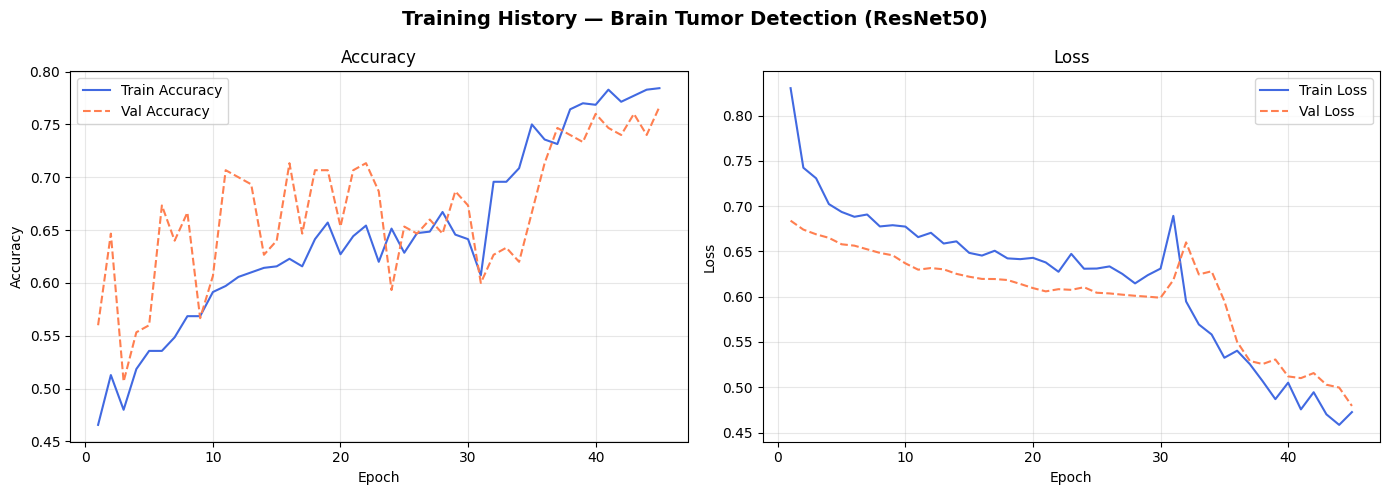

  ✓ Saved: training_curves.png

═══════════════════════════════════════════════════════
  STEP 11 ▸ Test-Set Evaluation
═══════════════════════════════════════════════════════
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step  

  Accuracy  : 0.8267
  Precision : 0.7952
  Recall    : 0.8800   ← (sensitivity – minimize missed tumors)
  F1-Score  : 0.8354

  Classification Report:
              precision    recall  f1-score   support

     healthy       0.87      0.77      0.82        75
       tumor       0.80      0.88      0.84        75

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



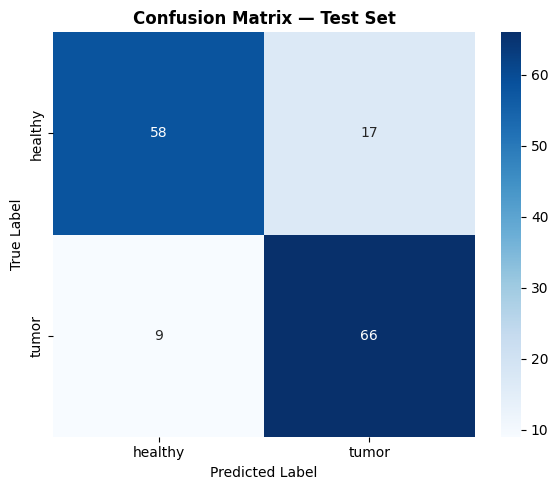

  ✓ Saved: confusion_matrix.png

  ✓ Model saved to: brain_tumor_resnet50_best.keras

═══════════════════════════════════════════════════════
  ✅ Pipeline Complete!
═══════════════════════════════════════════════════════

  Files saved:
    brain_tumor_resnet50_best.keras  →  trained model
    training_curves.png              →  accuracy & loss curves
    confusion_matrix.png             →  test-set confusion matrix
    prediction_result.png            →  last single-image prediction

  To predict a new image:
    from brain_tumor_detection_resnet50 import predict_mri
    result = predict_mri("your_mri_image.jpg")



In [2]:
"""
=============================================================
  Brain Tumor Detection using ResNet50 Transfer Learning
=============================================================
Dataset  : Tumor MRI images (2538) | Healthy MRI images (2087)
Model    : ResNet50 (pretrained on ImageNet) + custom head
Task     : Binary classification — Tumor vs No-Tumor
Sampling : 500 images per class for faster training & fairness
=============================================================
"""

# ─────────────────────────────────────────────
#  STEP 0 ▸ Imports
# ─────────────────────────────────────────────
import os
import random
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


# ─────────────────────────────────────────────
#  STEP 1 ▸ Configuration  (edit paths here)
# ─────────────────────────────────────────────
class Config:
    # ── Paths ──────────────────────────────────
    TUMOR_DIR   = r"E:/2 nd semester/tumor"          # folder with tumor MRI images
    HEALTHY_DIR = r"E:/2 nd semester/healthy/Healthy"       # folder with healthy MRI images

    # ── Sampling ───────────────────────────────
    SAMPLES_PER_CLASS = 500             # 500 tumor + 500 healthy = 1000 total

    # ── Image settings ─────────────────────────
    IMG_SIZE   = (224, 224)             # ResNet50 expects 224x224
    CHANNELS   = 3                      # RGB (ResNet50 is pretrained on RGB)

    # ── Split ratios ───────────────────────────
    VAL_SIZE   = 0.15                   # 15 % validation
    TEST_SIZE  = 0.15                   # 15 % test  (70 % remaining → train)

    # ── Training hyper-params ──────────────────
    BATCH_SIZE     = 16
    EPOCHS         = 30
    LEARNING_RATE  = 0.0001
    DROPOUT_RATE   = 0.5

    # ── Output paths ───────────────────────────
    MODEL_SAVE_PATH = "brain_tumor_resnet50_best.keras"
    SPLIT_DATA_DIR  = "split_dataset"   # temp dir for train/val/test split


cfg = Config()


# ─────────────────────────────────────────────
#  STEP 2 ▸ Data Organisation & Understanding
# ─────────────────────────────────────────────
def analyse_dataset():
    print("\n" + "═"*55)
    print("  STEP 2 ▸ Dataset Analysis")
    print("═"*55)

    for label, folder in [("Tumor", cfg.TUMOR_DIR), ("Healthy", cfg.HEALTHY_DIR)]:
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        print(f"  {label:10s}: {len(files):>5} images  →  {folder}")

    print(f"\n  Sampling  : {cfg.SAMPLES_PER_CLASS} images per class")
    print(f"  Total used: {cfg.SAMPLES_PER_CLASS * 2} images")
    print(f"  Input size: {cfg.IMG_SIZE[0]}×{cfg.IMG_SIZE[1]} px  |  RGB")


analyse_dataset()


# ─────────────────────────────────────────────
#  STEP 3 ▸ Sample 500 images per class
#           Build stratified train/val/test split
# ─────────────────────────────────────────────
def sample_and_split():
    print("\n" + "═"*55)
    print("  STEP 3 ▸ Sampling & Stratified Split")
    print("═"*55)

    def get_images(folder, n):
        all_imgs = [os.path.join(folder, f) for f in os.listdir(folder)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        return random.sample(all_imgs, min(n, len(all_imgs)))

    tumor_imgs   = get_images(cfg.TUMOR_DIR,   cfg.SAMPLES_PER_CLASS)
    healthy_imgs = get_images(cfg.HEALTHY_DIR, cfg.SAMPLES_PER_CLASS)

    all_paths  = tumor_imgs + healthy_imgs
    all_labels = ["tumor"] * len(tumor_imgs) + ["healthy"] * len(healthy_imgs)

    # ── Stratified split: train / val+test ─────
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_paths, all_labels,
        test_size=(cfg.VAL_SIZE + cfg.TEST_SIZE),
        stratify=all_labels,
        random_state=42
    )

    val_ratio = cfg.VAL_SIZE / (cfg.VAL_SIZE + cfg.TEST_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_ratio),
        stratify=y_temp,
        random_state=42
    )

    print(f"  Train : {len(X_train)} images  "
          f"(tumor={y_train.count('tumor')}, healthy={y_train.count('healthy')})")
    print(f"  Val   : {len(X_val)}  images  "
          f"(tumor={y_val.count('tumor')}, healthy={y_val.count('healthy')})")
    print(f"  Test  : {len(X_test)}  images  "
          f"(tumor={y_test.count('tumor')}, healthy={y_test.count('healthy')})")

    # ── Copy into folder structure for flow_from_directory ──
    for split, paths, labels in [("train", X_train, y_train),
                                  ("val",   X_val,   y_val),
                                  ("test",  X_test,  y_test)]:
        for cls in ["tumor", "healthy"]:
            os.makedirs(os.path.join(cfg.SPLIT_DATA_DIR, split, cls), exist_ok=True)

        for src, lbl in zip(paths, labels):
            dst = os.path.join(cfg.SPLIT_DATA_DIR, split, lbl, os.path.basename(src))
            shutil.copy2(src, dst)

    print("\n  ✓ Split dataset written to:", cfg.SPLIT_DATA_DIR)
    return X_train, X_val, X_test, y_train, y_val, y_test


X_train, X_val, X_test, y_train, y_val, y_test = sample_and_split()


# ─────────────────────────────────────────────
#  STEP 4 ▸ Image Preprocessing & Augmentation
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 4 ▸ Preprocessing + Augmentation")
print("═"*55)

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,          # normalise 0–255  →  0–1
    rotation_range=15,           # small rotations (MRI orientation matters)
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)   # NO augmentation

train_gen = train_datagen.flow_from_directory(
    os.path.join(cfg.SPLIT_DATA_DIR, "train"),
    target_size=cfg.IMG_SIZE,
    color_mode="rgb",
    batch_size=cfg.BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(cfg.SPLIT_DATA_DIR, "val"),
    target_size=cfg.IMG_SIZE,
    color_mode="rgb",
    batch_size=cfg.BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(cfg.SPLIT_DATA_DIR, "test"),
    target_size=cfg.IMG_SIZE,
    color_mode="rgb",
    batch_size=cfg.BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Class index → label mapping  (e.g. {'healthy': 0, 'tumor': 1})
class_indices = train_gen.class_indices
label_map = {v: k for k, v in class_indices.items()}
print(f"\n  Class indices : {class_indices}")
print(f"  Label map     : {label_map}")


# ─────────────────────────────────────────────
#  STEP 5 ▸ Handle Class Imbalance
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 5 ▸ Class Weights (imbalance handling)")
print("═"*55)

n_total   = len(train_gen.classes)
n_healthy = np.sum(train_gen.classes == class_indices["healthy"])
n_tumor   = np.sum(train_gen.classes == class_indices["tumor"])

w_healthy = n_total / (2 * n_healthy)
w_tumor   = n_total / (2 * n_tumor)

class_weights = {class_indices["healthy"]: w_healthy,
                 class_indices["tumor"]:   w_tumor}

print(f"  healthy weight : {w_healthy:.4f}")
print(f"  tumor   weight : {w_tumor:.4f}")


# ─────────────────────────────────────────────
#  STEP 6 ▸ Model Architecture — ResNet50
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 6 ▸ Model — ResNet50 Transfer Learning")
print("═"*55)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*cfg.IMG_SIZE, cfg.CHANNELS)
)

# Freeze base model layers (feature extractor)
base_model.trainable = False

# Custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(cfg.DROPOUT_RATE)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation="sigmoid")(x)   # Binary output

model = Model(inputs=base_model.input, outputs=output)

print(f"\n  Total params   : {model.count_params():,}")
print(f"  Trainable      : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"  Non-trainable  : {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")


# ─────────────────────────────────────────────
#  STEP 7 ▸ Compile
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 7 ▸ Compilation")
print("═"*55)

model.compile(
    optimizer=Adam(learning_rate=cfg.LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)
print("  Optimizer : Adam  |  LR:", cfg.LEARNING_RATE)
print("  Loss      : Binary Cross-Entropy")
print("  Metrics   : Accuracy, Precision, Recall")


# ─────────────────────────────────────────────
#  STEP 8 ▸ Callbacks
# ─────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=cfg.MODEL_SAVE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


# ─────────────────────────────────────────────
#  STEP 9 ▸ Train (frozen base)
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 9 ▸ Training (Phase 1 — frozen ResNet50 base)")
print("═"*55)

history = model.fit(
    train_gen,
    epochs=cfg.EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ── Fine-tuning Phase 2: unfreeze top layers ──
print("\n  ── Phase 2: Fine-tuning top 30 ResNet50 layers ──")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=cfg.LEARNING_RATE / 10),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

history_ft = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


# ─────────────────────────────────────────────
#  STEP 10 ▸ Plot Training Curves
# ─────────────────────────────────────────────
def plot_history(h1, h2=None):
    def merge(key):
        v = h1.history.get(key, [])
        if h2:
            v = v + h2.history.get(key, [])
        return v

    epochs_range = range(1, len(merge("accuracy")) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History — Brain Tumor Detection (ResNet50)",
                 fontsize=14, fontweight="bold")

    # Accuracy
    axes[0].plot(epochs_range, merge("accuracy"),     label="Train Accuracy",  color="royalblue")
    axes[0].plot(epochs_range, merge("val_accuracy"), label="Val Accuracy",    color="coral", linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, merge("loss"),         label="Train Loss",      color="royalblue")
    axes[1].plot(epochs_range, merge("val_loss"),     label="Val Loss",        color="coral", linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("  ✓ Saved: training_curves.png")


plot_history(history, history_ft)


# ─────────────────────────────────────────────
#  STEP 11 ▸ Evaluation on Test Set
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  STEP 11 ▸ Test-Set Evaluation")
print("═"*55)

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_gen.classes

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=class_indices["tumor"])
rec  = recall_score(y_true, y_pred,    pos_label=class_indices["tumor"])
f1   = f1_score(y_true, y_pred,        pos_label=class_indices["tumor"])

print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}   ← (sensitivity – minimize missed tumors)")
print(f"  F1-Score  : {f1:.4f}")

print("\n  Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=list(class_indices.keys())))

# ── Confusion Matrix ─────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(class_indices.keys()),
            yticklabels=list(class_indices.keys()))
plt.title("Confusion Matrix — Test Set", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("  ✓ Saved: confusion_matrix.png")


# ─────────────────────────────────────────────
#  STEP 12 ▸ Save the Best Model
# ─────────────────────────────────────────────
model.save(cfg.MODEL_SAVE_PATH)
print(f"\n  ✓ Model saved to: {cfg.MODEL_SAVE_PATH}")


# ─────────────────────────────────────────────
#  STEP 13 ▸ Predict on a New MRI Image
# ─────────────────────────────────────────────
def predict_mri(image_path: str, model_path: str = cfg.MODEL_SAVE_PATH):
    """
    Predict whether a new brain MRI image contains a tumor.

    Parameters
    ----------
    image_path : str   Path to the MRI image (.jpg / .png)
    model_path : str   Path to saved .keras model

    Returns
    -------
    dict  with keys: label, confidence, raw_probability
    """
    print("\n" + "═"*55)
    print("  STEP 13 ▸ Predicting New MRI Image")
    print("═"*55)

    # Load model
    loaded_model = tf.keras.models.load_model(model_path)

    # Preprocess image (same pipeline as training)
    img = load_img(image_path, target_size=cfg.IMG_SIZE, color_mode="rgb")
    img_array = img_to_array(img) / 255.0          # normalise
    img_array = np.expand_dims(img_array, axis=0)  # add batch dim → (1, 224, 224, 3)

    # Predict
    prob  = loaded_model.predict(img_array, verbose=0)[0][0]
    label = label_map[int(prob > 0.5)]
    confidence = prob if prob > 0.5 else 1 - prob

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    color = "red" if label == "tumor" else "green"
    plt.title(f"Prediction: {label.upper()}\nConfidence: {confidence:.2%}",
              fontsize=14, color=color, fontweight="bold")
    plt.tight_layout()
    plt.savefig("prediction_result.png", dpi=150)
    plt.show()

    print(f"\n  Image      : {image_path}")
    print(f"  Prediction : {label.upper()}")
    print(f"  Confidence : {confidence:.2%}")
    print(f"  Raw prob   : {prob:.4f}  (>0.5 → tumor  class = {class_indices})")

    return {"label": label, "confidence": float(confidence),
            "raw_probability": float(prob)}


# ── USAGE EXAMPLE ─────────────────────────────
# Uncomment and change the path to test on a real image:
#
# result = predict_mri("path/to/your/new_mri.jpg")
# print(result)
#
# ─────────────────────────────────────────────
print("\n" + "═"*55)
print("  ✅ Pipeline Complete!")
print("═"*55)
print("""
  Files saved:
    brain_tumor_resnet50_best.keras  →  trained model
    training_curves.png              →  accuracy & loss curves
    confusion_matrix.png             →  test-set confusion matrix
    prediction_result.png            →  last single-image prediction

  To predict a new image:
    from brain_tumor_detection_resnet50 import predict_mri
    result = predict_mri("your_mri_image.jpg")
""")


═══════════════════════════════════════════════════════
  STEP 13 ▸ Predicting New MRI Image
═══════════════════════════════════════════════════════


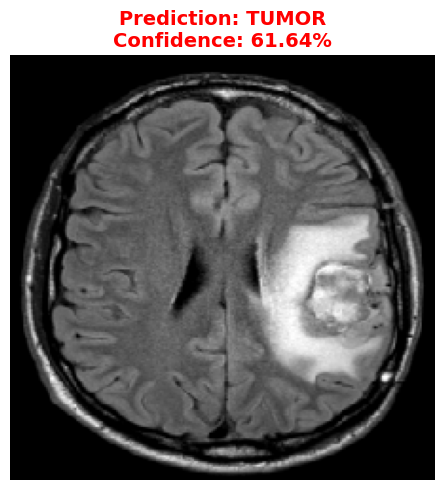


  Image      : Cancer (1).png
  Prediction : TUMOR
  Confidence : 61.64%
  Raw prob   : 0.6164  (>0.5 → tumor  class = {'healthy': 0, 'tumor': 1})
{'label': 'tumor', 'confidence': 0.6163737773895264, 'raw_probability': 0.6163737773895264}


In [6]:
# At the bottom of brain_tumor_detection_resnet50.py, uncomment this:
result = predict_mri("Cancer (1).png")
print(result)


═══════════════════════════════════════════════════════
  STEP 13 ▸ Predicting New MRI Image
═══════════════════════════════════════════════════════


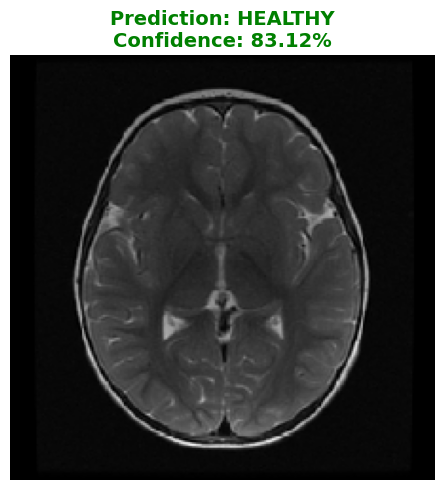


  Image      : Not Cancer  (2).jpeg
  Prediction : HEALTHY
  Confidence : 83.12%
  Raw prob   : 0.1688  (>0.5 → tumor  class = {'healthy': 0, 'tumor': 1})
{'label': 'healthy', 'confidence': 0.8312379121780396, 'raw_probability': 0.16876210272312164}


In [7]:
# At the bottom of brain_tumor_detection_resnet50.py, uncomment this:
result = predict_mri("Not Cancer  (2).jpeg")
print(result)


═══════════════════════════════════════════════════════
  STEP 13 ▸ Predicting New MRI Image
═══════════════════════════════════════════════════════


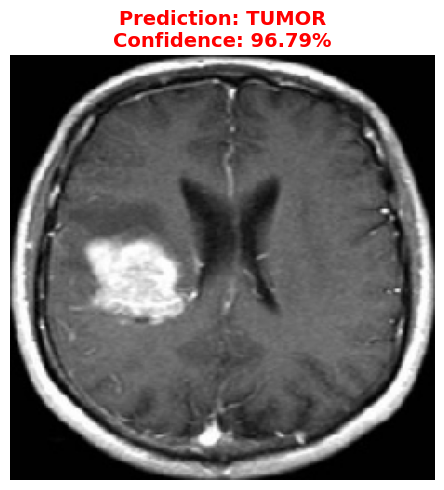


  Image      : Cancer (45).tif
  Prediction : TUMOR
  Confidence : 96.79%
  Raw prob   : 0.9679  (>0.5 → tumor  class = {'healthy': 0, 'tumor': 1})
{'label': 'tumor', 'confidence': 0.9678887128829956, 'raw_probability': 0.9678887128829956}


In [8]:
result = predict_mri("Cancer (45).tif")
print(result)


═══════════════════════════════════════════════════════
  STEP 13 ▸ Predicting New MRI Image
═══════════════════════════════════════════════════════


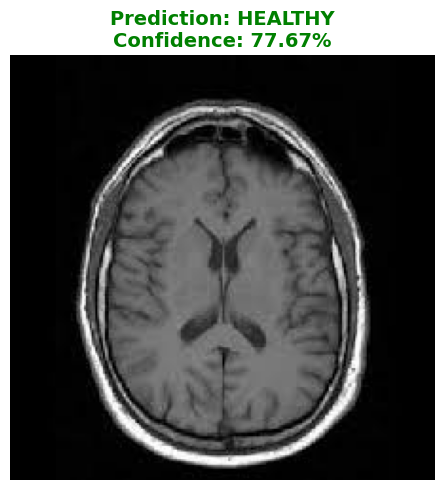


  Image      : Not Cancer  (46).jpg
  Prediction : HEALTHY
  Confidence : 77.67%
  Raw prob   : 0.2233  (>0.5 → tumor  class = {'healthy': 0, 'tumor': 1})
{'label': 'healthy', 'confidence': 0.7767419219017029, 'raw_probability': 0.22325807809829712}


In [9]:
result = predict_mri("Not Cancer  (46).jpg")
print(result)


═══════════════════════════════════════════════════════
  STEP 13 ▸ Predicting New MRI Image
═══════════════════════════════════════════════════════


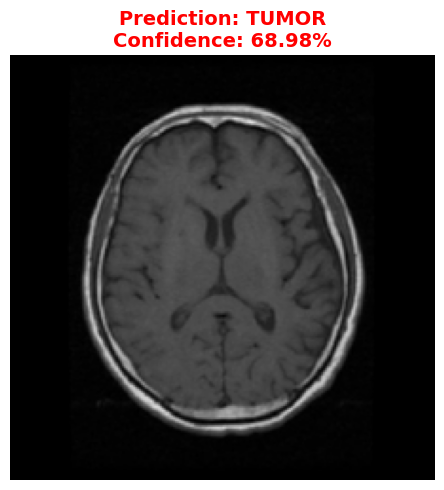


  Image      : Not Cancer  (3).jpeg
  Prediction : TUMOR
  Confidence : 68.98%
  Raw prob   : 0.6898  (>0.5 → tumor  class = {'healthy': 0, 'tumor': 1})
{'label': 'tumor', 'confidence': 0.6898493766784668, 'raw_probability': 0.6898493766784668}


In [13]:
result = predict_mri("Not Cancer  (3).jpeg")
print(result)